In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm
from hmmlearn import hmm

class InstitutionalEngine:
    @staticmethod
    def black_scholes_put(S, K, T, r, sigma):
        T = np.maximum(T, 0.00001)
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
        vega = S * norm.pdf(d1) * np.sqrt(T)
        theta = -(S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))) - r * K * np.exp(-r * T) * norm.cdf(-d2)
        
        return price, delta, vega, theta

In [98]:
class RegimeModel:
    def __init__(self, n_components=3):
        self.model = hmm.GaussianHMM(n_components=n_components, covariance_type="full", n_iter=2000, random_state=42)

    def prepare_data(self, ticker_spy="SPY", ticker_vix="^VIX"):
        data = yf.download([ticker_spy, ticker_vix], start="2015-01-01")['Close']
        df = data.copy()
        df['SPY_Ret'] = np.log(df[ticker_spy] / df[ticker_spy].shift(1))
        df['VIX_Ret'] = np.log(df[ticker_vix] / df[ticker_vix].shift(1))
        return df.dropna()

    def fit_predict(self, df):
        obs = df[['SPY_Ret', 'VIX_Ret']].values
        self.model.fit(obs)
        df['Regime'] = self.model.predict(obs)
        
        order = np.argsort([df[df['Regime'] == i]['^VIX'].mean() for i in range(3)])
        rank = {old: new for new, old in enumerate(order)}
        df['Regime'] = df['Regime'].map(rank)
        return df

In [ ]:
class AdvancedBacktester:
    def __init__(self, initial_cash=100000, commission=0.0001):
        self.initial_cash = initial_cash
        self.commission = commission
        self.engine = InstitutionalEngine()

    def run(self, df):
        T_init = 90/365
        r = 0.04
        portfolio_vals = [self.initial_cash]
        current_put = None 
        
        for i in range(1, len(df)):
            row = df.iloc[i]
            prev_row = df.iloc[i-1]
            equity_val = portfolio_vals[-1] * np.exp(row['SPY_Ret'])
            pnl_option = 0
            
            if row['Regime'] > 0:
                S, sigma = row['SPY'], row['^VIX'] / 100
                
                if current_put is None:
                    p, d, v, t = self.engine.black_scholes_put(S, S, T_init, r, sigma)
                    units = portfolio_vals[-1] / S
                    current_put = {'S_entry': S, 'p_entry': p, 'age': 0, 'units': units}
                    equity_val -= (p * units) + (portfolio_vals[-1] * self.commission)
                else:
                    current_put['age'] += 1
                    t_rem = T_init - (current_put['age'] / 365)
                    
                    if t_rem <= 0.005:
                        current_put = None
                    else:
                        p_now, d_now, v_now, t_now = self.engine.black_scholes_put(S, current_put['S_entry'], t_rem, r, sigma)
                        pnl_option = (p_now - current_put['p_entry']) * current_put['units']
            else:
                current_put = None
            
            portfolio_vals.append(equity_val + pnl_option)

        df['Strategy'] = portfolio_vals
        df['Benchmark'] = (df['SPY'] / df['SPY'].iloc[0]) * self.initial_cash
        return df

[*********************100%***********************]  2 of 2 completed


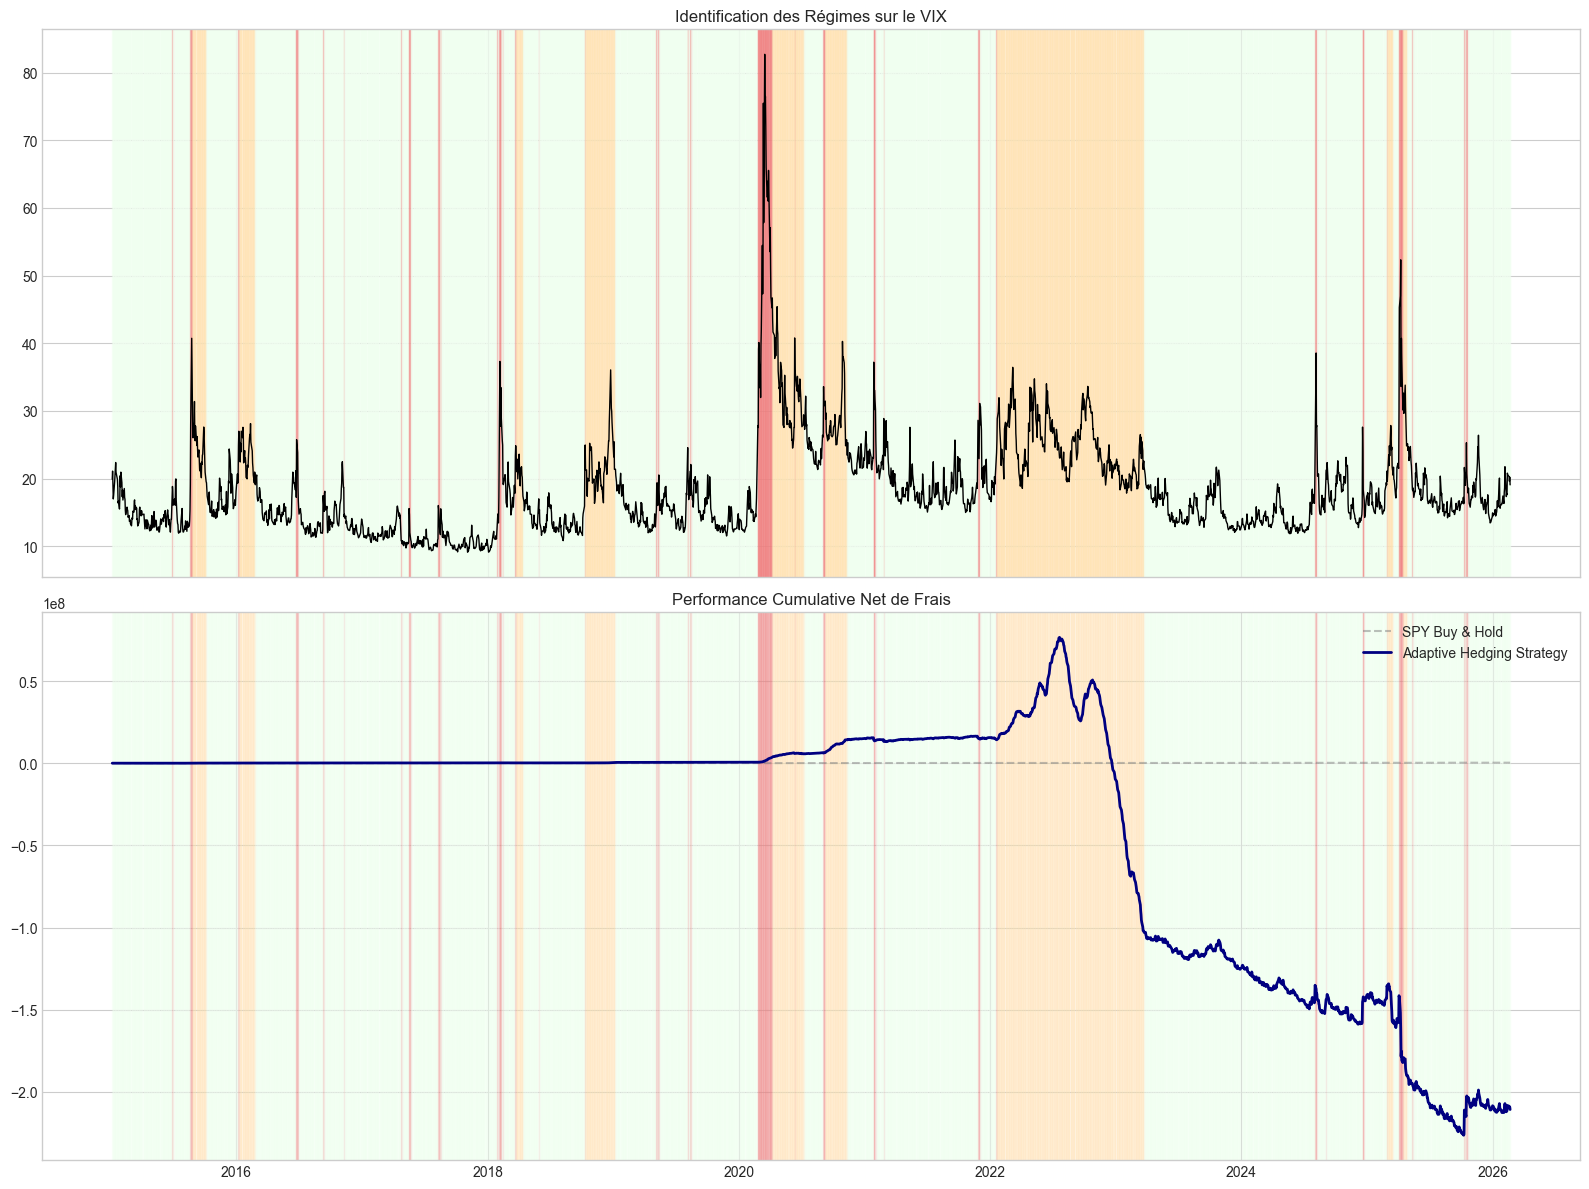

Benchmark -> Sharpe: 0.81, Max Drawdown: -33.72%
Strategy -> Sharpe: 0.65, Max Drawdown: -395.12%


In [ ]:
def finalize_project(df):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
    
    colors = {0: 'honeydew', 1: 'moccasin', 2: 'lightcoral'}
    
    ax1.plot(df.index, df['^VIX'], color='black', lw=1)
    for i in range(len(df)-1):
        ax1.axvspan(df.index[i], df.index[i+1], color=colors[df['Regime'].iloc[i]], alpha=0.4)
    ax1.set_title("Identification des Régimes sur le VIX")

    ax2.plot(df.index, df['Benchmark'], label='SPY Buy & Hold', color='gray', alpha=0.5, ls='--')
    ax2.plot(df.index, df['Strategy'], label='Adaptive Hedging Strategy', color='navy', lw=2)
    for i in range(len(df)-1):
        ax2.axvspan(df.index[i], df.index[i+1], color=colors[df['Regime'].iloc[i]], alpha=0.2)
    ax2.set_title("Performance Cumulative Net de Frais")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    for name, col in [('Benchmark', 'Benchmark'), ('Strategy', 'Strategy')]:
        rets = df[col].pct_change().dropna()
        sharpe = (rets.mean() / rets.std()) * np.sqrt(252)
        dd = (df[col] / df[col].cummax() - 1).min()
        print(f"{name} -> Sharpe: {sharpe:.2f}, Max Drawdown: {dd*100:.2f}%")

model = RegimeModel()
df_final = model.prepare_data()
df_final = model.fit_predict(df_final)
df_final = AdvancedBacktester().run(df_final)
finalize_project(df_final)